# Pertemuan 13 - Data Science

**Nama:** Krisno Hasmilu Hutabarat  
**NIM:** 240401010102  
**Kelas:** IF401  
**Mata Kuliah:** Data Science

---
## Langkah 0: Import Library

In [1]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'  # supresss TF log

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix,
                              accuracy_score)
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

print("Semua library berhasil diimport!")
print(f"TensorFlow version: {tf.__version__}")

Semua library berhasil diimport!
TensorFlow version: 2.20.0


---
## Langkah 1: Generate & Eksplorasi Dataset Non-Linear

Membuat dataset `make_moons` — dua kelas berbentuk bulan sabit yang **tidak bisa dipisahkan dengan satu garis lurus** — lalu memvisualisasikannya untuk membangun intuisi mengapa model linear tidak cukup.

In [2]:
# Generate dataset non-linear make_moons
X, y = make_moons(n_samples=300, noise=0.2, random_state=42)

print('Shape X:', X.shape)
print('Shape y:', y.shape)
print('Distribusi kelas:', np.bincount(y))

Shape X: (300, 2)
Shape y: (300,)
Distribusi kelas: [150 150]


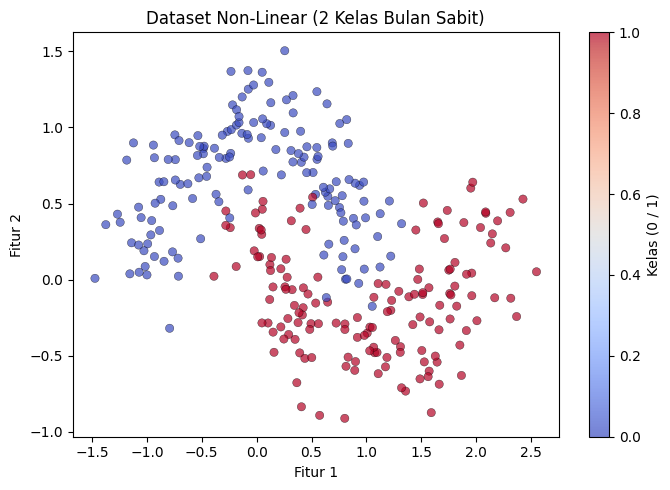

In [3]:
# Visualisasi dataset: dua kelas saling melengkung dan bertautan
plt.figure(figsize=(7, 5))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', alpha=0.7, edgecolors='k', linewidths=0.3)
plt.title('Dataset Non-Linear (2 Kelas Bulan Sabit)')
plt.xlabel('Fitur 1')
plt.ylabel('Fitur 2')
plt.colorbar(label='Kelas (0 / 1)')
plt.tight_layout()
plt.show()

In [4]:
# Ilustrasi: Decision Boundary model LINEAR (Logistic Regression) pada data ini
from sklearn.linear_model import LogisticRegression as LR_demo

X_tr_d, X_te_d, y_tr_d, y_te_d = train_test_split(X, y, test_size=0.2, random_state=42)
lr_demo = LR_demo().fit(X_tr_d, y_tr_d)
print(f'Akurasi Logistic Regression (linear): {lr_demo.score(X_te_d, y_te_d):.3f}')
print('→ Model linear tidak dapat memisahkan data bulan sabit dengan baik.')

Akurasi Logistic Regression (linear): 0.900
→ Model linear tidak dapat memisahkan data bulan sabit dengan baik.


### Interpretasi EDA
- Kedua kelas **saling melengkung dan bertautan** — tidak ada garis lurus yang bisa memisahkannya dengan sempurna.
- Logistic Regression (model linear) mendapatkan akurasi yang terbatas pada data ini, karena decision boundary-nya berupa garis lurus.
- **Neural Network dengan activation function non-linear (ReLU)** mampu membentuk decision boundary yang melengkung, sehingga cocok untuk data seperti ini.

---
## Langkah 2: Bangun & Latih Neural Network Sederhana

Membangun arsitektur neural network dengan dua hidden layer (ReLU) dan satu output layer (Sigmoid), kemudian melatihnya selama 30 epoch.

In [5]:
# Train-Test Split
X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=0.2, random_state=42)

print(f'Training : {X_tr.shape[0]} sampel')
print(f'Test     : {X_te.shape[0]} sampel')

Training : 240 sampel
Test     : 60 sampel


In [6]:
# Bangun arsitektur Neural Network
model = Sequential([
    Dense(16, activation='relu', input_shape=(2,)),
    Dense(8,  activation='relu'),
    Dense(1,  activation='sigmoid')
])

# Tampilkan arsitektur
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │            48 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 193 (772.00 B)

 Trainable params: 193 (772.00 B)

 Non-trainable params: 0 (0.00 B)

**Penjelasan arsitektur:**
| Layer | Neuron | Aktivasi | Peran |
|---|---|---|---|
| Input | 2 | — | Menerima 2 fitur (Fitur 1 & Fitur 2) |
| Hidden 1 | 16 | ReLU | Menangkap pola non-linear tingkat pertama |
| Hidden 2 | 8 | ReLU | Memperhalus representasi fitur |
| Output | 1 | Sigmoid | Menghasilkan probabilitas kelas (0–1) |

In [ ]:
# Compile model
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Latih model 30 epoch
history = model.fit(
    X_tr, y_tr,
    epochs=30,
    validation_split=0.2,
    verbose=0
)

print('Training selesai.')
print(f'Epoch terakhir — Loss: {history.history["loss"][-1]:.4f} | Accuracy: {history.history["accuracy"][-1]:.4f}')

---
## Langkah 3: Evaluasi & Visualisasi Kurva Belajar

Mengevaluasi model pada data uji, lalu memplot **kurva akurasi training vs validasi** untuk melihat apakah model belajar dengan baik atau mengalami overfitting.

In [ ]:
# Evaluasi pada data uji
loss, acc = model.evaluate(X_te, y_te, verbose=0)
print(f'Loss pada data uji    : {loss:.4f}')
print(f'Akurasi pada data uji : {acc:.3f}')

In [ ]:
# Kurva pembelajaran: Accuracy Training vs Validasi
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'],     color='#028090', label='Training')
plt.plot(history.history['val_accuracy'], color='#D85A30', label='Validasi')
plt.xlabel('Epoch')
plt.ylabel('Akurasi')
plt.title('Kurva Akurasi')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'],     color='#028090', label='Training')
plt.plot(history.history['val_loss'], color='#D85A30', label='Validasi')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Kurva Loss')
plt.legend()

plt.suptitle('Kurva Pembelajaran Neural Network', fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# Visualisasi Decision Boundary Neural Network
h = 0.02
x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))

Z = model.predict(np.c_[xx.ravel(), yy.ravel()], verbose=0)
Z = (Z > 0.5).astype(int).reshape(xx.shape)

plt.figure(figsize=(7, 5))
plt.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm',
            edgecolors='k', linewidths=0.3, alpha=0.8)
plt.title('Decision Boundary Neural Network (make_moons)')
plt.xlabel('Fitur 1')
plt.ylabel('Fitur 2')
plt.tight_layout()
plt.show()

In [ ]:
# Classification report neural network
y_pred_nn = (model.predict(X_te, verbose=0) > 0.5).astype(int)
print(classification_report(y_te, y_pred_nn, target_names=['Kelas 0', 'Kelas 1']))

### Interpretasi Kurva Belajar
- Kurva akurasi training dan validasi yang **saling mendekat dan stabil** menunjukkan model belajar dengan baik tanpa overfitting signifikan.
- Jika kedua kurva **saling menjauh** (training tinggi, validasi rendah), itu indikasi overfitting — model menghafal data latih.
- **Decision boundary yang melengkung** adalah bukti nyata bahwa neural network dengan ReLU mampu menangkap pola non-linear yang tidak bisa ditangani model linear.

---
## Langkah 4: Siapkan Dataset Ulasan Produk

Membuat 40 ulasan produk sintetis berbahasa Indonesia berlabel positif (1) / negatif (0).

In [ ]:
# Dataset 40 ulasan produk sintetis berbahasa Indonesia
ulasan = [
    # Positif (1)
    'Barangnya bagus banget, pengiriman cepat',
    'Sangat puas, akan beli lagi',
    'Recommended, harga sesuai kualitas',
    'Produk original, kemasan rapi dan aman',
    'Pelayanan ramah, respon cepat',
    'Kualitas sangat bagus, sesuai foto',
    'Pengiriman kilat, barang tidak rusak',
    'Harga terjangkau tapi kualitas premium',
    'Sudah beli tiga kali, selalu memuaskan',
    'Barang sampai tepat waktu, kondisi sempurna',
    'Penjual responsif, produk sesuai deskripsi',
    'Sangat memuaskan, akan order lagi',
    'Kualitas terbaik di kelasnya, worth it',
    'Packaging aman, produk bagus sekali',
    'Pengalaman belanja menyenangkan, recommended',
    'Barang original, tidak mengecewakan',
    'Cepat diproses, produk memuaskan hati',
    'Seller terpercaya, barang sesuai ekspektasi',
    'Produk awet dan berkualitas tinggi',
    'Belanja lagi pasti, puas banget',
    # Negatif (0)
    'Kualitas jelek, tidak sesuai deskripsi',
    'Kecewa, barang rusak saat sampai',
    'Buruk sekali, tidak sesuai ekspektasi',
    'Pengiriman sangat lambat, mengecewakan',
    'Produk palsu, bukan original',
    'Barang tidak sesuai foto, tipu-tipu',
    'Kecewa berat, tidak akan beli lagi',
    'Penjual tidak responsif, barang cacat',
    'Kualitas sangat buruk, mudah rusak',
    'Tidak rekomendasikan, buang-buang uang',
    'Packaging buruk, barang pecah di jalan',
    'Deskripsi tidak jujur, barang mengecewakan',
    'Respon penjual lama, barang tidak sesuai',
    'Produk cepat rusak, tidak awet sama sekali',
    'Sangat kecewa, uang terbuang percuma',
    'Barang datang terlambat dan dalam kondisi rusak',
    'Tidak sesuai ukuran, penjual tidak mau refund',
    'Kualitas rendah, tidak layak dibeli',
    'Penipuan, barang tidak dikirim tepat waktu',
    'Sangat buruk, komplain tidak ditanggapi'
]

label = [1]*20 + [0]*20

print(f'Total ulasan  : {len(ulasan)}')
print(f'Positif (1)   : {sum(label)}')
print(f'Negatif (0)   : {len(label) - sum(label)}')
print()
print('Contoh ulasan positif:', ulasan[0])
print('Contoh ulasan negatif:', ulasan[20])

---
## Langkah 5: Ubah Teks Menjadi TF-IDF

Mengubah seluruh ulasan menjadi representasi numerik TF-IDF, lalu melihat kata-kata dengan bobot tertinggi.

In [ ]:
# Ubah teks menjadi vektor TF-IDF
tfidf = TfidfVectorizer()
X_text = tfidf.fit_transform(ulasan)

print('Shape matriks TF-IDF:', X_text.shape)
print(f'Jumlah kata unik (vocabulary): {len(tfidf.get_feature_names_out())}')
print()
print('10 kata pertama dalam vocabulary:')
print(tfidf.get_feature_names_out()[:10])

In [ ]:
# Tampilkan kata dengan skor TF-IDF rata-rata tertinggi
import numpy as np

tfidf_scores = np.asarray(X_text.mean(axis=0)).flatten()
words = tfidf.get_feature_names_out()

top_words = pd.DataFrame({
    'Kata': words,
    'TF-IDF rata-rata': tfidf_scores
}).sort_values('TF-IDF rata-rata', ascending=False).head(15)

print('15 kata dengan skor TF-IDF rata-rata tertinggi:')
print(top_words.to_string(index=False))

In [ ]:
# Visualisasi kata dengan TF-IDF tertinggi
plt.figure(figsize=(8, 5))
top15 = top_words.sort_values('TF-IDF rata-rata')
plt.barh(top15['Kata'], top15['TF-IDF rata-rata'], color='#1D9E75')
plt.xlabel('TF-IDF Rata-rata')
plt.title('15 Kata dengan Skor TF-IDF Tertinggi')
plt.tight_layout()
plt.show()

### Interpretasi TF-IDF
- Kata yang memiliki **skor TF-IDF tinggi** adalah kata yang sering muncul di ulasan tertentu tapi jarang di ulasan lain — kata-kata yang benar-benar mencirikan sentimen.
- Kata seperti **"bagus"**, **"puas"**, **"memuaskan"** akan memiliki skor tinggi di ulasan positif, sedangkan **"kecewa"**, **"rusak"**, **"buruk"** akan tinggi di ulasan negatif.
- Kata-kata umum seperti **"dan"**, **"di"**, **"tidak"** cenderung memiliki IDF rendah karena muncul di hampir semua dokumen.

---
## Langkah 6: Latih Model Klasifikasi Sentimen & Evaluasi

Melatih model Logistic Regression di atas representasi TF-IDF, lalu mengevaluasinya dan menguji prediksi sentimen pada kalimat baru.

In [ ]:
# Train-Test Split untuk data teks
Xt_tr, Xt_te, yt_tr, yt_te = train_test_split(
    X_text, label, test_size=0.2, random_state=42, stratify=label)

print(f'Training: {Xt_tr.shape[0]} ulasan')
print(f'Test    : {Xt_te.shape[0]} ulasan')

In [ ]:
# Latih model Logistic Regression
model_sentimen = LogisticRegression(max_iter=1000)
model_sentimen.fit(Xt_tr, yt_tr)

akurasi = model_sentimen.score(Xt_te, yt_te)
print(f'Akurasi model sentimen: {akurasi:.3f}')

In [ ]:
# Classification report lengkap
y_pred_sent = model_sentimen.predict(Xt_te)
print(classification_report(yt_te, y_pred_sent,
      target_names=['Negatif', 'Positif']))

In [ ]:
# Confusion matrix
cm = confusion_matrix(yt_te, y_pred_sent)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negatif', 'Positif'],
            yticklabels=['Negatif', 'Positif'])
plt.title('Confusion Matrix — Model Sentimen TF-IDF')
plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.tight_layout()
plt.show()

In [ ]:
# Uji prediksi sentimen pada kalimat baru
kalimat_baru = [
    'Pelayanan sangat memuaskan dan ramah',
    'Barang rusak dan tidak sesuai ekspektasi',
    'Pengiriman cepat, produk berkualitas bagus',
    'Sangat kecewa, tidak akan beli lagi'
]

pred = model_sentimen.predict(tfidf.transform(kalimat_baru))
proba = model_sentimen.predict_proba(tfidf.transform(kalimat_baru))

print('Hasil prediksi sentimen:')
print()
for kalimat, p, prob in zip(kalimat_baru, pred, proba):
    sentimen = 'POSITIF ✓' if p == 1 else 'NEGATIF ✗'
    print(f'  "{kalimat}"')
    print(f'   → {sentimen} (confidence: {max(prob):.2f})')
    print()

In [ ]:
# Visualisasi kata dengan bobot koefisien tertinggi (positif vs negatif)
coef = model_sentimen.coef_[0]
feature_names = tfidf.get_feature_names_out()

top_pos = pd.DataFrame({'Kata': feature_names, 'Koefisien': coef})           .sort_values('Koefisien', ascending=False).head(10)
top_neg = pd.DataFrame({'Kata': feature_names, 'Koefisien': coef})           .sort_values('Koefisien').head(10)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].barh(top_pos['Kata'][::-1], top_pos['Koefisien'][::-1], color='#1D9E75')
axes[0].set_title('10 Kata Paling Positif')
axes[0].set_xlabel('Koefisien')

axes[1].barh(top_neg['Kata'], top_neg['Koefisien'], color='#D85A30')
axes[1].set_title('10 Kata Paling Negatif')
axes[1].set_xlabel('Koefisien')

plt.suptitle('Kata-kata Paling Berpengaruh pada Prediksi Sentimen', fontweight='bold')
plt.tight_layout()
plt.show()

### Interpretasi Model Sentimen
- Kata-kata dengan **koefisien positif tinggi** (hijau) adalah kata-kata yang sangat kuat mengindikasikan ulasan positif.
- Kata-kata dengan **koefisien negatif tinggi** (merah) adalah kata-kata yang sangat kuat mengindikasikan ulasan negatif.
- Model TF-IDF + Logistic Regression sangat **transparan dan interpretable** — kita bisa langsung melihat kata mana yang mendorong prediksi.
- Keterbatasan: model ini tidak memahami konteks — kalimat seperti *"tidak bagus"* bisa salah diklasifikasikan karena kata *"bagus"* memiliki bobot positif tinggi meskipun diikuti negasi.

## Kesimpulan

Pada pertemuan ini, saya mempelajari dua topik lanjutan dalam Data Science: **Deep Learning melalui Artificial Neural Network** dan **NLP melalui TF-IDF**. Neural Network sederhana dengan dua hidden layer (ReLU) berhasil memisahkan dataset bulan sabit non-linear yang tidak bisa ditangani model linear, membuktikan bahwa activation function non-linear adalah kunci kemampuan neural network menangkap pola kompleks — kurva belajar training dan validasi yang stabil mengindikasikan model berhasil generalisasi tanpa overfitting. Untuk analisis sentimen, pipeline TF-IDF + Logistic Regression terbukti efektif sebagai baseline yang cepat dan interpretable, dengan keunggulan transparansi (dapat melihat kata-kata paling berpengaruh) namun memiliki keterbatasan dalam memahami konteks seperti negasi atau sarkasme. Kesimpulan utama dari pertemuan ini adalah bahwa TF-IDF cocok sebagai titik awal yang murah dan mudah dipahami, sedangkan arsitektur Transformer (BERT, GPT) diperlukan ketika pemahaman konteks mendalam menjadi prioritas dan sumber daya komputasi tersedia.